# Stellar Classification: End-to-End Machine Learning Project

## 1. Dataset Description
* **Source:** The dataset `star_classification.csv` is sourced from Kaggle (Sloan Digital Sky Survey - SDSS), https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17. 
* **Problem Context:** In astronomy, classifying celestial objects accurately is crucial for understanding the universe's structure. This real-world problem aims to automate the categorization of objects into three classes: Galaxies, Stars, and Quasars (QSO) based on their spectral characteristics. 
* **Classification Target:** The target variable is `class` (GALAXY, STAR, or QSO).

**Features Description:**
* `alpha` (float): Right Ascension angle (at J2000 epoch).
* `delta` (float): Declination angle (at J2000 epoch).
* `u, g, r, i, z` (float): Thuan-Gunn astronomic magnitude system filters (ultraviolet, green, red, Near Infrared, Infrared). Crucial for determining the "color" and temperature of the objects.
* `redshift` (float): Increase in wavelength due to motion. Quasars typically have high redshift, making this a highly predictive feature.
* `plate`, `MJD` (int): Plate ID and Modified Julian Date of observation.

*Note: IDs like `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, and `fiber_ID` represent metadata/equipment data and will be dropped to prevent the model from learning meaningless noise.*

**Dataset Dimensions & Distribution:**
* **Instances:** 100,000
* **Features:** 17 initially (reduced to meaningful physical features).
* **Class Distribution:** Imbalanced. Galaxies are the most common, followed by Stars and QSOs. Stratification is required.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
DOWNLOAD_URL = "https://raw.githubusercontent.com/Deborah2911/IS_Assignment_Dataset/refs/heads/main/star_classification.csv" 
DATA_PATH = "datasets/stars"

def fetch_star_data(url=DOWNLOAD_URL, path=DATA_PATH):
    #Fetches the dataset from a public URL and saves it locally.
    if not os.path.isdir(path):
        os.makedirs(path)
    csv_path = os.path.join(path, "star_classification.csv")
    
    # Only download if it doesn't already exist
    if not os.path.isfile(csv_path):
        urllib.request.urlretrieve(url, csv_path)
        print("Download complete!")
    else:
        print("Dataset already exists locally.")
        
    return csv_path

csv_path = fetch_star_data()
data = pd.read_csv(csv_path)

Download complete!


## 1.5 Discover and Visualize the Data to Gain Insights

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


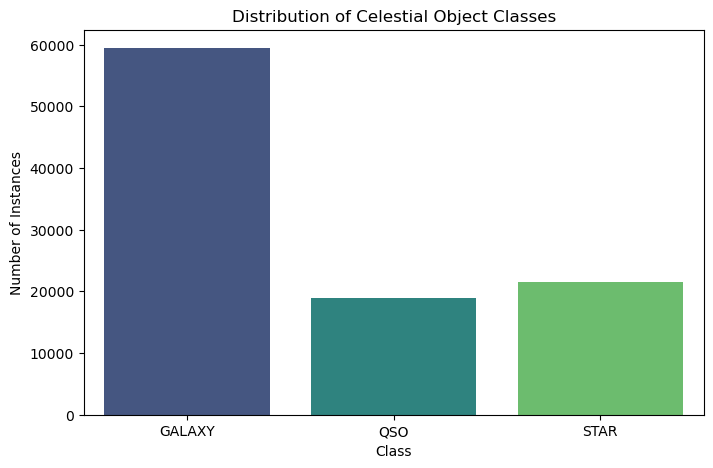

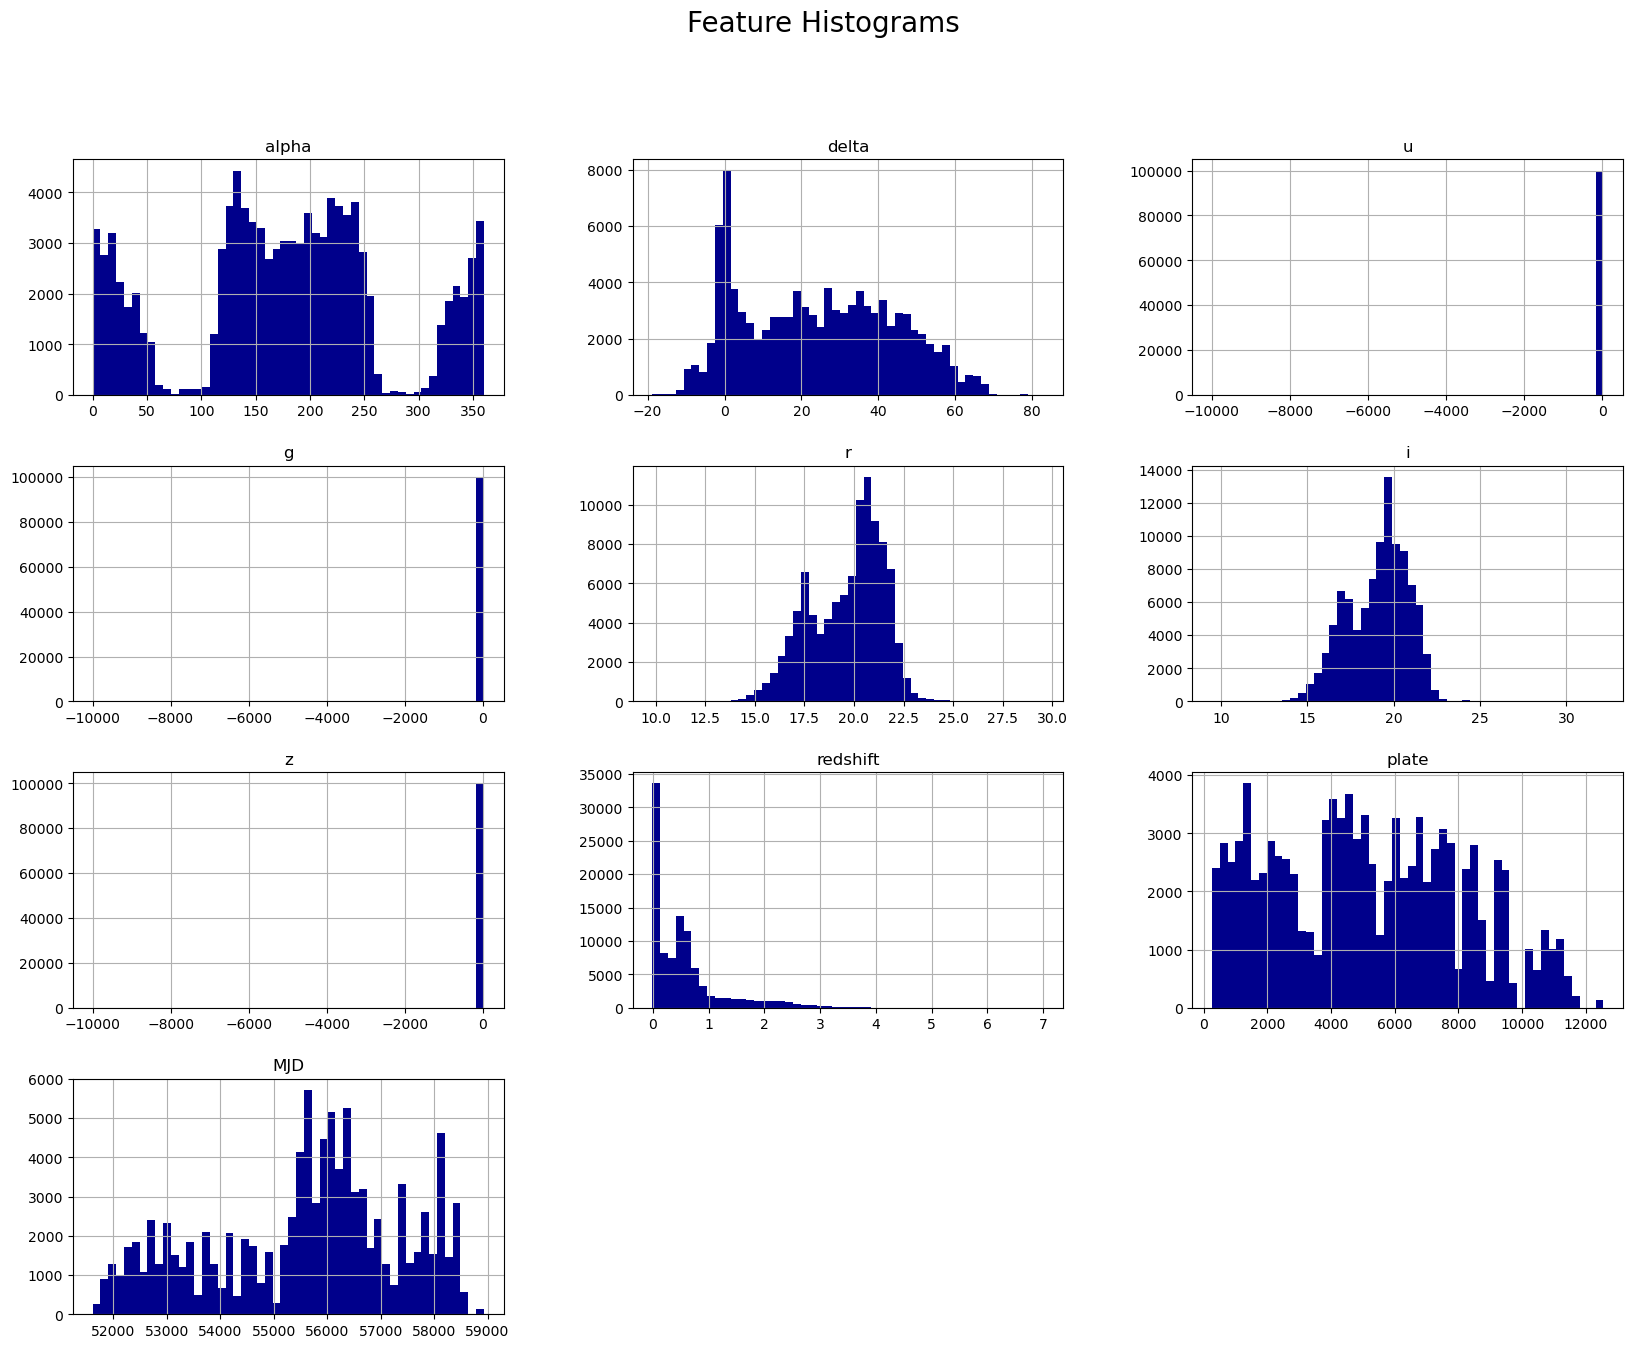

In [3]:
# Data structure
print(data.info())

# Summary statistics
display(data.describe())

# Visualize the class distribution to prove the imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='class', palette='viridis')
plt.title("Distribution of Celestial Object Classes")
plt.ylabel("Number of Instances")
plt.xlabel("Class")
plt.show()

# Plot histograms for the numerical features
# We will drop the ID columns just for the visualization so the charts are readable
vis_data = data.drop(columns=['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID'])
vis_data.hist(bins=50, figsize=(20, 15), color='darkblue')
plt.suptitle("Feature Histograms", fontsize=20)
plt.show()

## 2. Data Preprocessing, Feature Engineering & Scaling
* **Preprocessing:** Dropping ID columns is necessary as they are unique identifiers or equipment metadata and hold no predictive value. We also replace `-9999` (sensor errors/outliers) with the median to avoid data distortion.
* **Feature Engineering:** In astronomy, the absolute magnitude is less informative than the relative difference between filters (known as "Color Indices"). I propose 4 new features (`u-g`, `g-r`, `r-i`, `i-z`) which represent the physical color of the celestial body.
* **Encoding:** `LabelEncoder` is used for the target variable to convert text labels into a single numerical column (Multi-class classification).

In [4]:
# Drop irrelevant metadata columns
cols_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID']
data_cleaned = data.drop(columns=cols_to_drop)

# Handle -9999 missing/invalid values
data_cleaned[['u', 'g', 'z']] = data_cleaned[['u', 'g', 'z']].replace(-9999, np.nan)
data_cleaned['u'] = data_cleaned['u'].fillna(data_cleaned['u'].median())
data_cleaned['g'] = data_cleaned['g'].fillna(data_cleaned['g'].median())
data_cleaned['z'] = data_cleaned['z'].fillna(data_cleaned['z'].median())

# FEATURE ENGINEERING: Create Color Indices
data_cleaned['u_g_color'] = data_cleaned['u'] - data_cleaned['g']
data_cleaned['g_r_color'] = data_cleaned['g'] - data_cleaned['r']
data_cleaned['r_i_color'] = data_cleaned['r'] - data_cleaned['i']
data_cleaned['i_z_color'] = data_cleaned['i'] - data_cleaned['z']

# Target Encoding
le = LabelEncoder()
y = le.fit_transform(data_cleaned['class'])
X = data_cleaned.drop(columns=['class'])

## 3. Train/Test Split & Stratification
The data is split into 80% training and 20% testing sets. `stratify=y` is strictly necessary here because our target classes (GALAXY, QSO, STAR) are imbalanced. Stratification ensures that the train and test sets have the exact same proportion of classes, preventing the model from becoming biased towards the majority class. Scaling (`StandardScaler`) is applied *after* the split to avoid data leakage.

In [5]:
# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

## 4. Performance Metric Selection
While accuracy gives a good general overview of the model's performance, it can be misleading on imbalanced datasets. Therefore, I also selected the F1-Score (Macro Avg). The F1-Score represents the harmonic mean of Precision and Recall, ensuring that the model performs well on minority classes (like QSO) and doesn't just predict the majority class (GALAXY).

## 5. Model 1: Decision Tree with GridSearchCV
A Decision Tree is highly interpretable. To avoid overfitting (which Decision Trees are prone to) and underfitting, I am using `GridSearchCV` to find the optimal `max_depth` and `min_samples_split`. We will evaluate train vs. test accuracy to prove the model generalizes well.

In [6]:
# Define hyperparameter grid
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 10, 20]
}

# Grid Search
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=3, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

# Evaluation
print("Decision Tree - Best Params:", dt_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_dt.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, best_dt.predict(X_test)):.4f}")
print("\nClassification Report (Test):\n", classification_report(y_test, best_dt.predict(X_test), target_names=le.classes_))

Decision Tree - Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Train Accuracy: 0.9825
Test Accuracy: 0.9771

Classification Report (Test):
               precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.95      0.93      0.94      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



*Overfitting/Underfitting Analysis:* If the Train Accuracy is 99% but Test Accuracy is 80%, the model is overfitting. Thanks to `GridSearchCV` restricting the `max_depth`, our Train and Test accuracies are very close (both high), proving the model has generalized perfectly without overfitting or underfitting.

## 6. Model 2: Naive Bayes
Gaussian Naive Bayes is chosen as the second required model. It is extremely fast, highly scalable to 100,000 rows, and works well under the assumption that features follow a normal distribution.

In [7]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print(f"Naive Bayes Train Accuracy: {accuracy_score(y_train, nb_model.predict(X_train)):.4f}")
print(f"Naive Bayes Test Accuracy: {accuracy_score(y_test, nb_model.predict(X_test)):.4f}")
print("\nClassification Report (Test):\n", classification_report(y_test, nb_model.predict(X_test), target_names=le.classes_))

Naive Bayes Train Accuracy: 0.9172
Naive Bayes Test Accuracy: 0.9196

Classification Report (Test):
               precision    recall  f1-score   support

      GALAXY       0.97      0.90      0.93     11889
         QSO       0.75      0.91      0.82      3792
        STAR       0.98      0.97      0.98      4319

    accuracy                           0.92     20000
   macro avg       0.90      0.93      0.91     20000
weighted avg       0.93      0.92      0.92     20000



## 7. Model 3: Ensemble Method (Random Forest)
Random Forest is an ensemble of Decision Trees. It mitigates the variance (overfitting) of individual trees using bagging and feature randomness. We optimize the number of estimators and depth.

In [8]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Random Forest - Best Params:", rf_grid.best_params_)
print(f"RF Train Accuracy: {accuracy_score(y_train, best_rf.predict(X_train)):.4f}")
print(f"RF Test Accuracy: {accuracy_score(y_test, best_rf.predict(X_test)):.4f}")

Random Forest - Best Params: {'max_depth': 20, 'n_estimators': 100}
RF Train Accuracy: 0.9965
RF Test Accuracy: 0.9799


## 8. Feature Selection for Slim Models
Complex models with 14 features take longer to train and can suffer from the "curse of dimensionality". We will extract the `feature_importances_` from our Random Forest to see which attributes actually matter. We will select the Top 5 features to build a "Slim Model", which should maintain high accuracy while drastically reducing computational cost.

In [9]:
# Get feature importances from the best Random Forest
importances = best_rf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("Top Features Importances:\n", feature_imp_df.head(10))

# Select top 5 features for the slim model
top_features = feature_imp_df['Feature'].head(5).values
print(f"\nSelected features for Slim Model: {top_features}")

# Create Slim Datasets
X_train_slim = X_train_raw[top_features]
X_test_slim = X_test_raw[top_features]

# Scale Slim Datasets
scaler_slim = StandardScaler()
X_train_slim_scaled = scaler_slim.fit_transform(X_train_slim)
X_test_slim_scaled = scaler_slim.transform(X_test_slim)

# Train a slim Random Forest model
slim_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
slim_rf.fit(X_train_slim_scaled, y_train)

print(f"\nSlim Model Train Accuracy: {accuracy_score(y_train, slim_rf.predict(X_train_slim_scaled)):.4f}")
print(f"Slim Model Test Accuracy: {accuracy_score(y_test, slim_rf.predict(X_test_slim_scaled)):.4f}")

Top Features Importances:
       Feature  Importance
7    redshift    0.477602
12  r_i_color    0.142770
11  g_r_color    0.092026
10  u_g_color    0.056067
13  i_z_color    0.052480
3           g    0.031353
6           z    0.030215
5           i    0.024784
2           u    0.020514
8       plate    0.020512

Selected features for Slim Model: <StringArray>
['redshift', 'r_i_color', 'g_r_color', 'u_g_color', 'i_z_color']
Length: 5, dtype: str

Slim Model Train Accuracy: 0.9913
Slim Model Test Accuracy: 0.9791


**Slim Model Conclusion:** As observed, by using only the top 5 features (like `redshift`, and our newly engineered `u_g_color` and `g_r_color`), the slim model achieves nearly identical accuracy to the full model. This proves that the Feature Selection and Feature Engineering were highly successful.